## Path configuration

In [1]:
from pathlib import Path
import os

PROJECT_NAME = "MALDIAlign"

cwd = Path().resolve()

# Walk upwards until we find the project folder
target = None
for parent in [cwd] + list(cwd.parents):
    if parent.name == PROJECT_NAME:
        target = parent
        break

# If the project folder is found and we are not already there, then change cwd
if target is not None and target != cwd:
    os.chdir(target)

print("Working directory:", os.getcwd())

Working directory: /export/usuarios01/agnavarr/MALDIAlign


## Imports

In [2]:
import pickle
import numpy as np
import pandas as pd

# utils
from utils.config import load_config
from utils.data import *
from utils.metrics import *
from utils.viz import *

# tools
from sklearn.model_selection import train_test_split

# models
from sklearn.ensemble import RandomForestClassifier

## Data loading

In [4]:
cfg = load_config()

driams_dict  = load_driams(cfg["data"]["DRIAMS_REDUCED_PKL"])
marisma_dict = load_marisma(cfg["data"]["MARISMa_REDUCED_PKL"])
msumg_dict   = load_msumg(cfg["data"]["MSUMG_PKL"])  # ya filtra agar
rki_dict     = load_rki(cfg["data"]["RKI_PKL"])

# Unpack
data_driams, label_driams, meta_driams = driams_dict["data"], driams_dict["label"], driams_dict["meta"]
data_marisma, label_marisma, meta_marisma = marisma_dict["data"], marisma_dict["label"], marisma_dict["meta"]
data_msumg, label_msumg, meta_msumg = msumg_dict["data"], msumg_dict["label"], msumg_dict["meta"]
data_rki, label_rki, meta_rki = rki_dict["data"], rki_dict["label"], rki_dict["meta"]


# =========================
# SPLIT DRIAMS BY HOSPITAL
# =========================
maskA = meta_driams["hospital"] == "DRIAMS_A"
maskB = meta_driams["hospital"] == "DRIAMS_B"
maskC = meta_driams["hospital"] == "DRIAMS_C"
maskD = meta_driams["hospital"] == "DRIAMS_D"

dataA, labelA, metaA = data_driams[maskA], label_driams[maskA], meta_driams[maskA]
dataB, labelB, metaB = data_driams[maskB], label_driams[maskB], meta_driams[maskB]
dataC, labelC, metaC = data_driams[maskC], label_driams[maskC], meta_driams[maskC]
dataD, labelD, metaD = data_driams[maskD], label_driams[maskD], meta_driams[maskD]


# =========================
# NORMALIZATION (row min-max)
# =========================
dataA = row_minmax_normalize(dataA)
dataB = row_minmax_normalize(dataB)
dataC = row_minmax_normalize(dataC)
dataD = row_minmax_normalize(dataD)
data_marisma = row_minmax_normalize(data_marisma)
data_msumg = row_minmax_normalize(data_msumg)
data_rki = row_minmax_normalize(data_rki)


# =========================
# LOAD SPLITS
# =========================
with open(
    "/export/usuarios01/agnavarr/MALDIAlign/experiments/finetuning/output_data/splits_20260211_151606/splits_idx.pkl",
    "rb"
) as f:
    splits_idx = pickle.load(f)


def select(data, label, meta, idx):
    return (
        data[idx],
        label[idx],
        meta.iloc[idx].reset_index(drop=True),
    )


# =========================
# OOD TEST SUBSETS (D & MS)
# =========================
dataD_test, labelD_test, metaD_test = select(
    dataD, labelD, metaD,
    splits_idx["DRIAMS_D"]["test"]
)

dataMS_test, labelMS_test, metaMS_test = select(
    data_msumg, label_msumg, meta_msumg,
    splits_idx["MS-UMG"]["test"]
)


# =========================
# CONCATENATE FINAL DATASET
# =========================
data_all = np.vstack([
    dataA,
    dataB,
    dataC,
    dataD_test,
    data_marisma,
    data_rki,
    dataMS_test
])

label_all = np.concatenate([
    labelA,
    labelB,
    labelC,
    labelD_test,
    label_marisma,
    label_rki,
    labelMS_test
])

meta_all = pd.concat([
    metaA,
    metaB,
    metaC,
    metaD_test,
    meta_marisma,
    meta_rki,
    metaMS_test
], ignore_index=True)


## Original space (train on DRIAMS-ABC + MARISMA + RKI, test on DRIAMS-D, MS-UMG)

In [5]:
data_train = np.vstack([dataA, dataB, dataC, data_marisma, data_rki])
label_train = np.concatenate([labelA, labelB, labelC, label_marisma, label_rki])
meta_train = pd.concat([metaA, metaB, metaC, meta_marisma, meta_rki], ignore_index=True)

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    data_train,
    label_train,
    test_size=0.2,
    stratify=label_train,
    shuffle=True,
    random_state=42
)

### Train

In [7]:
rf_final = RandomForestClassifier(
    n_estimators=200,
    max_depth=20,
    class_weight="balanced_subsample",
    n_jobs=-1,
    random_state=42
)
rf_final.fit(X_train, y_train)

,n_estimators,200
,criterion,'gini'
,max_depth,20
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


### Test


===== Metrics =====
Domain: DRIAMS-ABC + MARISMA + RKI
Balanced Accuracy: 0.9973
F1 Macro: 0.9977
Recall Macro: 0.9973
Specificity Macro: 0.9997



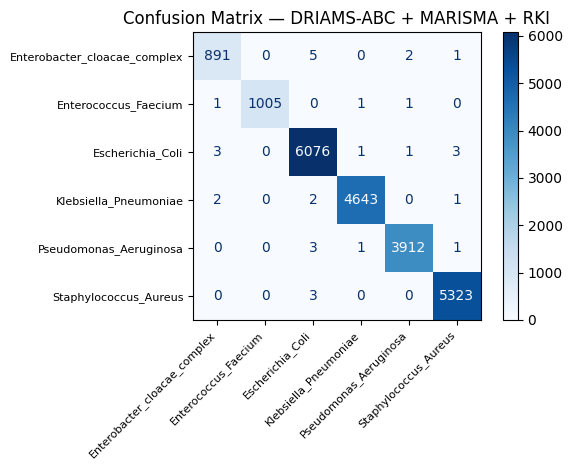


===== Metrics =====
Domain: DRIAMS-D
Balanced Accuracy: 0.9174
F1 Macro: 0.9047
Recall Macro: 0.9174
Specificity Macro: 0.9807



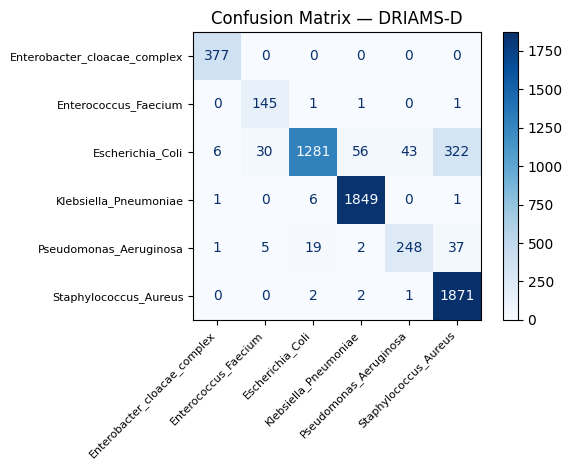


===== Metrics =====
Domain: MS-UMG
Balanced Accuracy: 0.8914
F1 Macro: 0.9276
Recall Macro: 0.8914
Specificity Macro: 0.9856



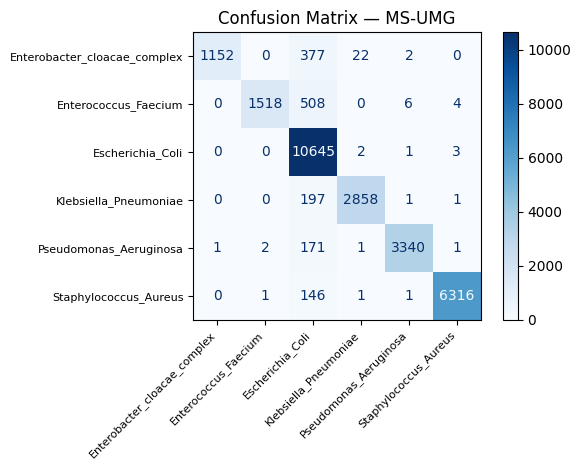

In [8]:
metrics_train = metrics_report(X_test, y_test, rf_final, "DRIAMS-ABC + MARISMA + RKI")
metrics_d = metrics_report(dataD_test, labelD_test, rf_final, "DRIAMS-D")
metrics_ms = metrics_report(dataMS_test, labelMS_test, rf_final, "MS-UMG")

print_metrics(metrics_train)
print_metrics(metrics_d)
print_metrics(metrics_ms)

## After domain alignment (zero-shot)

#### Utils

In [9]:
import torch
from models.deep.MultiVAEPrior import MultiVAE_Bernoulli_SpeciesPrior_Extended
from sklearn.ensemble import RandomForestClassifier

In [10]:
def load_model(model, path):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.load_state_dict(torch.load(path, map_location=device))
    model.to(device)
    model.eval()
    return model

def encode_latent(model, X, device, batch_size=256):
    model.eval()
    Z = []

    X_tensor = torch.tensor(X, dtype=torch.float32)

    loader = torch.utils.data.DataLoader(
        X_tensor,
        batch_size=batch_size,
        shuffle=False
    )

    with torch.no_grad():
        for x in loader:
            x = x.to(device)
            mu, _ = model.encoder(x)
            Z.append(mu.cpu().numpy())

    return np.vstack(Z)

#### Load and train

In [11]:
# multidecoder trained on DRIAMS-ABC + MARISMA + RKI
vae_path = "/export/usuarios01/agnavarr/MALDIAlign/experiments/results/finetuning_vae_multidecoder_prior/20260211_143045/model.pth"

backbone = MultiVAE_Bernoulli_SpeciesPrior_Extended(
    input_dim=data_all.shape[1],
    latent_dim=64,
    num_domains=5,
    n_species=len(np.unique(label_all))
)

vae = load_model(backbone, vae_path)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [12]:
Z_all = encode_latent(
    model=vae,
    X=data_all,
    device=device
)

print("Latent space shape:", Z_all.shape)

# Get latent representations
mask_A = meta_all["hospital"] == "DRIAMS_A"
mask_B = meta_all["hospital"] == "DRIAMS_B"
mask_C = meta_all["hospital"] == "DRIAMS_C"
mask_D = meta_all["hospital"] == "DRIAMS_D"
mask_M = meta_all["hospital"] == "MARISMA"
mask_RKI = meta_all["hospital"] == "RKI"
mask_MS = meta_all["hospital"] == "MS-UMG"

Z_A = Z_all[mask_A]
Z_B = Z_all[mask_B]
Z_C = Z_all[mask_C]
Z_D = Z_all[mask_D]
Z_M = Z_all[mask_M]
Z_MS = Z_all[mask_MS]
Z_RKI = Z_all[mask_RKI]

y_A = label_all[mask_A]
y_B = label_all[mask_B]
y_C = label_all[mask_C]
y_M = label_all[mask_M]
y_D = label_all[mask_D]
y_MS = label_all[mask_MS]
y_RKI = label_all[mask_RKI]

print(f"Z_A: {Z_A.shape}")
print(f"Z_B: {Z_B.shape}")
print(f"Z_C: {Z_C.shape}")
print(f"Z_D: {Z_D.shape}")
print(f"Z_MARISMA: {Z_M.shape}")
print(f"Z_M: {Z_M.shape}")
print(f"Z_RKI: {Z_RKI.shape}")

# Define train and test
Z_train, y_train_z = np.vstack([Z_A, Z_B, Z_C, Z_M, Z_RKI]), np.concatenate([y_A, y_B, y_C, y_M, y_RKI])
Z_test_D, y_test_D = Z_D, y_D
Z_test_MS, y_test_MS = Z_MS, y_MS

Latent space shape: (142995, 64)
Z_A: (27810, 64)
Z_B: (1986, 64)
Z_C: (2677, 64)
Z_D: (6308, 64)
Z_MARISMA: (76172, 64)
Z_M: (76172, 64)
Z_RKI: (764, 64)


In [13]:
Z_train, Z_test, y_train_z, y_test_z = train_test_split(
    Z_train,
    y_train_z,
    test_size=0.2,
    stratify=y_train_z,
    shuffle=True,
    random_state=42
)

In [14]:
rf_best = RandomForestClassifier(
    n_estimators=200,         
    max_depth=20,              
    class_weight="balanced_subsample",
    n_jobs=-1,
    random_state=42
)

rf_best.fit(Z_train, y_train_z)

,n_estimators,200
,criterion,'gini'
,max_depth,20
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


#### Test


===== Metrics =====
Domain: DRIAMS-ABC + MARISMA + RKI (test)
Balanced Accuracy: 0.9964
F1 Macro: 0.9966
Recall Macro: 0.9964
Specificity Macro: 0.9996



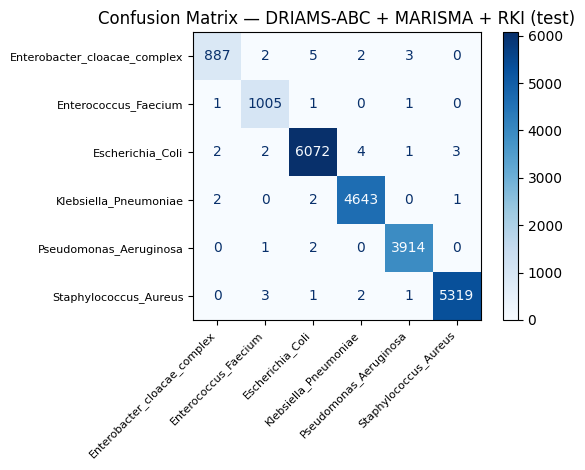


===== Metrics =====
Domain: DRIAMS-D (test)
Balanced Accuracy: 0.9151
F1 Macro: 0.8488
Recall Macro: 0.9151
Specificity Macro: 0.9824



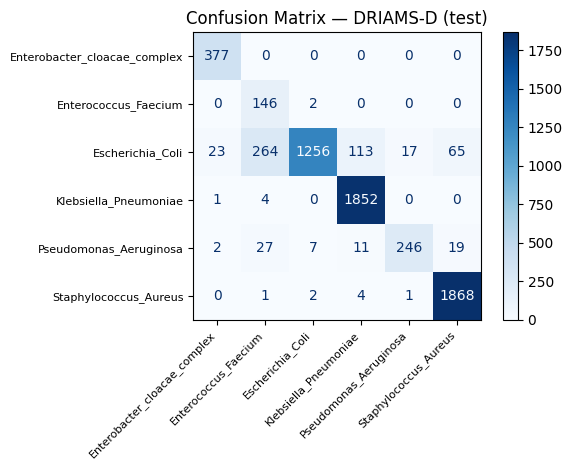


===== Metrics =====
Domain: MS-UMG (test)
Balanced Accuracy: 0.9216
F1 Macro: 0.9262
Recall Macro: 0.9216
Specificity Macro: 0.9881



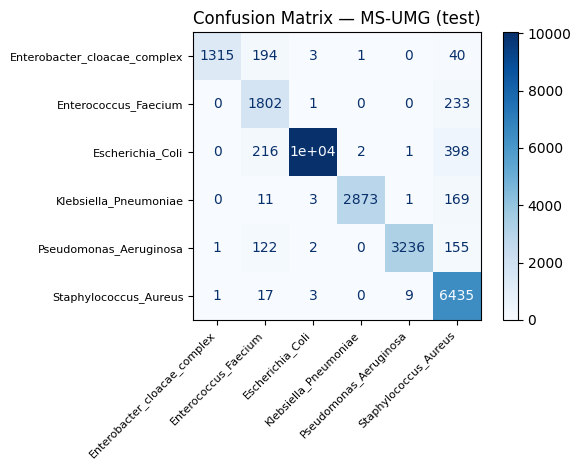

In [15]:
metrics_train = metrics_report(Z_test, y_test_z, rf_best, "DRIAMS-ABC + MARISMA + RKI (test)")
metrics_d = metrics_report(Z_test_D, y_test_D, rf_best, "DRIAMS-D (test)")
metrics_ms = metrics_report(Z_test_MS, y_test_MS, rf_best, "MS-UMG (test)")

print_metrics(metrics_train)
print_metrics(metrics_d)
print_metrics(metrics_ms)

## After domain alignment (few-shot learning)

### Load fine-tuned model on DRIAMS-D

In [ ]:
vae_path = "/export/usuarios01/agnavarr/MALDIAlign/experiments/finetuning/results/finetuning_vae_multidecoder_prior_ABC_MAR_RKI/20260211_223037/model_finetuned_D_only.pth"

backbone = MultiVAE_Bernoulli_SpeciesPrior_Extended(
    input_dim=data_all.shape[1],
    latent_dim=64,
    num_domains=6,
    n_species=len(np.unique(label_all))
)

vae = load_model(backbone, vae_path)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [17]:
FINETUNE_DOMAIN_MAP = {
    "DRIAMS_A": 0,
    "DRIAMS_B": 1,
    "DRIAMS_C": 2,
    "MARISMA":  3,
    "RKI":      4,
    "DRIAMS_D": 5,
}

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
Z_all = encode_latent(vae, data_all, device)

In [18]:
mask_D  = meta_all["hospital"] == "DRIAMS_D"
Z_D  = Z_all[mask_D]
y_D  = label_all[mask_D]


===== Metrics =====
Domain: DRIAMS-D (finetuned encoder)
Balanced Accuracy: 0.9527
F1 Macro: 0.9477
Recall Macro: 0.9527
Specificity Macro: 0.9951



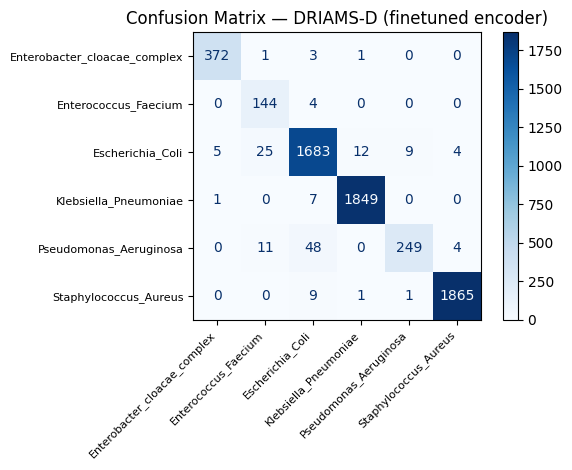

In [19]:
# Evaluate
metrics_d = metrics_report(
    Z_D,
    y_D,
    rf_best,
    "DRIAMS-D (finetuned encoder)"
)

print_metrics(metrics_d)

### Load fine-tuned model on MS-UMG

In [20]:
vae_path = "/export/usuarios01/agnavarr/MALDIAlign/experiments/finetuning/results/finetuning_vae_multidecoder_prior_ABC_MAR_RKI/20260211_224003/model_finetuned_MS_only.pth"

backbone = MultiVAE_Bernoulli_SpeciesPrior_Extended(
    input_dim=data_all.shape[1],
    latent_dim=64,
    num_domains=6,
    n_species=len(np.unique(label_all))
)

vae = load_model(backbone, vae_path)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [21]:
FINETUNE_DOMAIN_MAP = {
    "DRIAMS_A": 0,
    "DRIAMS_B": 1,
    "DRIAMS_C": 2,
    "MARISMA":  3,
    "RKI":      4,
    "MS-UMG": 5,
}

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
Z_all = encode_latent(vae, data_all, device)

In [22]:
mask_MS  = meta_all["hospital"] == "MS-UMG"
Z_MS  = Z_all[mask_MS]
y_MS  = label_all[mask_MS]


===== Metrics =====
Domain: MS-UMG (finetuned encoder)
Balanced Accuracy: 0.9512
F1 Macro: 0.9664
Recall Macro: 0.9512
Specificity Macro: 0.9922



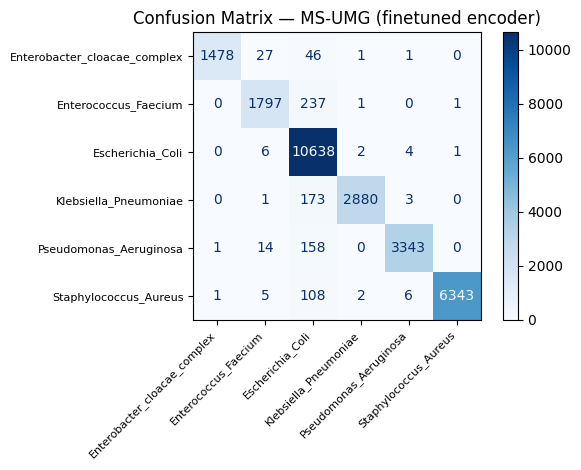

In [23]:
# Evaluate
metrics_ms = metrics_report(
    Z_MS,
    y_MS,
    rf_best,
    "MS-UMG (finetuned encoder)"
)

print_metrics(metrics_ms)